# IMPORTING LIBRARIES


In [1]:
!pip install jaro-winkler

In [2]:
import sys
!{sys.executable} -m pip install -U ydata-profiling[notebook]
!pip install jupyter-contrib-nbextensions

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.5/296.5 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 686.1/686.1 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.8/104.8 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 390.9/390.9 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.2/117.2 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 42.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 385.8/385.8 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.5/133.5 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.7/59.7 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━

In [3]:
!jupyter nbextension enable --py widgetsnbextension

Enabling notebook extension jupyter-js-widgets/extension...
Paths used for configuration of notebook: 
    	/root/.jupyter/nbconfig/notebook.json
Paths used for configuration of notebook: 
    	
      - Validating: OK
Paths used for configuration of notebook: 
    	/root/.jupyter/nbconfig/notebook.json


In [4]:
from google.colab import drive
drive.mount('/gdrive')
%cd /gdrive/My Drive/[DIQ]

Mounted at /gdrive
/gdrive/.shortcut-targets-by-id/1471IK5VXVHr5VkOUeVLv300ABFsCIrP5/[DIQ]


In [5]:
import os
print(os.getcwd())
print(os.listdir())

/gdrive/.shortcut-targets-by-id/1471IK5VXVHr5VkOUeVLv300ABFsCIrP5/[DIQ]
['Comune-di-Milano-Attivita-commerciali-di-media-e-grande-distribuzione.csv', '[2024-2025] DIQ - Assessment.ipynb', 'Milan_Commercial_Activities_Profiling_Report.html', 'Milan_Commercial_Activities_Profiling_Report.json', 'MI_COMM_ACTIVITIES.xlsx', '[2024-2025] DIQ - Wrangling.ipynb', 'Problemi nel Dataset.gdoc']


In [6]:
import pandas as pd
import numpy as np
import re
import json
import jaro
from ydata_profiling import ProfileReport

# IMPORTING DATASET

We start importing our dataset about commercial activities in the city of Milan

In [7]:
file_name = 'Comune-di-Milano-Attivita-commerciali-di-media-e-grande-distribuzione.csv'
MI_COMM_ACTIVITIES = pd.read_csv(file_name, sep=';', encoding='utf-16')

In [8]:
MI_COMM_ACTIVITIES.head()

,Settore Merceologico,Insegna,Ubicazione,Tipo Via,Via,Civico,Codice Via,ZD,Superficie vendita,Superficie altri usi,Superficie totale
0,NaN,NaN,PZA CORDUSIO N. 2 ;pza cordusio 002; isolato:4...,PZA,CORDUSIO,2.0,626,1,292,NaN,292
1,NaN,NaN,RIP DI PTA TICINESE N. 73 (z.d. 1),RIP,DI PTA TICINESE,73.0,5150,6,800,NaN,800
2,NaN,NaN,VIA ALBERICO DA ROSCIATE N. 5 (z.d. 7),VIA,ALBERICO DA ROSCIATE,5.0,6589,7,726,NaN,0
3,NaN,NaN,VIA ASTESANI ALESSANDRO N. 17 ; isolato:100; a...,VIA,ASTESANI ALESSANDRO,17.0,1558,9,370,NaN,370
4,NaN,NaN,VIA MONTE NAPOLEONE num.006/a; (z.d. 1),VIA,MONTE NAPOLEONE,NaN,219,1,270,NaN,270


#DATA QUALITY ASSESSMENT

> Since we assume that we don't have ground-truth information, accuracy can't be evaluated.
Moreover, we don't have information about currency or volatility of the data, so neither timeliness can't be evaluated

## COMPLETENESS

COMPLETENESS = NOT_NULL_CELLS / TOT_CELLS

In [9]:
NUM_ROWS = MI_COMM_ACTIVITIES.shape[0]
NUM_COLUMNS = MI_COMM_ACTIVITIES.shape[1]
NUM_CELLS = NUM_ROWS * NUM_COLUMNS
NULL_CELLS = MI_COMM_ACTIVITIES.isnull().sum().sum()
COMPLETENESS = (NUM_CELLS - NULL_CELLS) / NUM_CELLS
print("COMPLETENESS: ", round(COMPLETENESS*100,2), "%")

COMPLETENESS:  88.12 %


## CONSISTENCY

CONSISTENCY RULE: Superficie vendita + Superficie altri usi = Superficie totale


In [10]:
CONSISTENT_ROWS = MI_COMM_ACTIVITIES[MI_COMM_ACTIVITIES['Superficie vendita']+MI_COMM_ACTIVITIES['Superficie altri usi']==MI_COMM_ACTIVITIES['Superficie totale']].shape[0]

print(f"CONSISTENCY: {CONSISTENT_ROWS*100/NUM_ROWS:.2f}%")

CONSISTENCY: 15.81%


Very bad consistency: we will investigate the causes during the cleaning phase

## DATA PROFILING

We run Y Data Profiling tool to have a complete profiling of our data

In [11]:
MI_COMM_ACTIVITIES_PROFILE = ProfileReport(MI_COMM_ACTIVITIES, title="Milan Commercial Activities: Profiling Report")
MI_COMM_ACTIVITIES_PROFILE.to_file("Milan_Commercial_Activities_Profiling_Report.html")
MI_COMM_ACTIVITIES_PROFILE.to_file("Milan_Commercial_Activities_Profiling_Report.json")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Render JSON:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In order to have a recap of the main charachteristic of the dataset, let's display some values obtained directly from the profiling

In [12]:
file = open("Milan_Commercial_Activities_Profiling_Report.json")
MI_COMM_ACTIVITIES_JFILE = json.load(file)

### Dataset Level

In [13]:
num_rows = MI_COMM_ACTIVITIES_JFILE['table']['n']
num_columns = MI_COMM_ACTIVITIES_JFILE['table']['n_var']
num_cells = num_rows * num_columns
num_missing = MI_COMM_ACTIVITIES_JFILE['table']['n_cells_missing']
perc_missing = round(MI_COMM_ACTIVITIES_JFILE['table']['p_cells_missing']*100,2)
num_duplicated = MI_COMM_ACTIVITIES_JFILE['table']['n_duplicates']
perc_duplicated = round(MI_COMM_ACTIVITIES_JFILE['table']['p_duplicates']*100,2)

MI_INFO = {'Statistic' : ['NumOfRows', 'NumOfColumns', 'NumOfCells', 'NumOfMissingValues', '%MissingValues', 'NumOfDuplicatedRows', '%DuplicatedRows'],
           'Value' : [num_rows, num_columns, num_cells, num_missing, perc_missing, num_duplicated, perc_duplicated]}

for stat, val in zip(MI_INFO['Statistic'], MI_INFO['Value']):
    print(f"{stat}: {val}")


NumOfRows: 911
NumOfColumns: 11
NumOfCells: 10021
NumOfMissingValues: 1190
%MissingValues: 11.88
NumOfDuplicatedRows: 1
%DuplicatedRows: 0.11


### Feature level

The completeness and the distinctness of each feature can be found in the produced ProfileReport

# DATA CLEANING

To perform the data cleaning we will follow the complete pipeline presented during lectures. The data cleaning pipeline is composed of:

1. *Data normalization and standardization*

    1.1 Datatype conversion

    1.2 Normalization

2. *Error correction*

    2.1 Missing values

    2.2 Inconsistencies

    2.3 Outliers handling

3. *Duplicate detection*

    3.1 Exact matching
    
    3.2 Similarity measures

## 1. DATA NORMALIZATION AND STANDARDIZATION

### 1.1 DATATYPE CONVERSION

In [14]:
MI_COMM_ACTIVITIES.dtypes

,0
Settore Merceologico,object
Insegna,object
Ubicazione,object
Tipo Via,object
Via,object
Civico,float64
Codice Via,int64
ZD,int64
Superficie vendita,int64
Superficie altri usi,float64


We notice some inconsistencies in the data types of certain columns:
- 'Civico' is also of type float, but it should be an 'object' because in some special cases there can be characters or other non-integer values
- 'Superficie altri usi' is of type float, even though it contains integer values


In [15]:
MI_COMM_ACTIVITIES['Civico'] = MI_COMM_ACTIVITIES['Civico'].astype('object')
MI_COMM_ACTIVITIES['Superficie altri usi'] = MI_COMM_ACTIVITIES['Superficie altri usi'].astype('Int64')

---

### 1.2 NORMALIZATION

There are some Normalization issues:


- 'Settore alimentare' must be normalized

In [16]:
# Unique values of 'Settore alimentare'
MI_COMM_ACTIVITIES['Settore Merceologico'].unique()

array([nan, 'alimentare', 'alimentare;non alimentare', 'non alimentare',
       'non alimentare;tabella speciale carburanti',
       'non alimentare;tabella speciale monopolio',
       'tabella speciale carburanti', 'tabella speciale farmacie'],
      dtype=object)

In [17]:
# Lista delle categorie di settore merceologico
categories = ['alimentare', 'non alimentare', 'tabella speciale carburanti', 'tabella speciale monopolio', 'tabella speciale farmacie']

# Creazione di una nuova colonna per ciascun valore nella lista categories
for category in categories:
    MI_COMM_ACTIVITIES.loc[:, category] = MI_COMM_ACTIVITIES['Settore Merceologico'].apply(
        lambda x: float('nan') if pd.isnull(x) else (1 if category in [c.strip() for c in str(x).lower().split(';')] else 0)
    )

# Drop the original 'Settore Merceologico' column
MI_COMM_ACTIVITIES = MI_COMM_ACTIVITIES.drop(columns=['Settore Merceologico'])

# Change Datatype
MI_COMM_ACTIVITIES['alimentare'] = pd.to_numeric(MI_COMM_ACTIVITIES['alimentare'], errors='coerce').astype('Int64')
MI_COMM_ACTIVITIES['non alimentare'] = pd.to_numeric(MI_COMM_ACTIVITIES['non alimentare'], errors='coerce').astype('Int64')
MI_COMM_ACTIVITIES['tabella speciale carburanti'] = pd.to_numeric(MI_COMM_ACTIVITIES['tabella speciale carburanti'], errors='coerce').astype('Int64')
MI_COMM_ACTIVITIES['tabella speciale monopolio'] = pd.to_numeric(MI_COMM_ACTIVITIES['tabella speciale monopolio'], errors='coerce').astype('Int64')
MI_COMM_ACTIVITIES['tabella speciale farmacie'] = pd.to_numeric(MI_COMM_ACTIVITIES['tabella speciale farmacie'], errors='coerce').astype('Int64')

- 'Ubicazione' must be normalized

In [18]:
# print 'Ubicazione' of 10 randomly chosen records in the dataset
MI_COMM_ACTIVITIES['Ubicazione'].sample(10)

,Ubicazione
406,VIA DELL' ANNUNCIATA N. 2 angolo via manzoni;v...
103,PLE BOLOGNA N. 7 ; isolato:005; accesso: acces...
607,LGO TREVES CLAUDIO N. 2 ; isolato:247; accesso...
418,VIA FELTRE N. 30 ; isolato:067; accesso: acces...
12,PLE SELINUNTE N. 2 int. m.c.c. selinunte; (z.d...
672,VIA GAMBOLOITA N. 4 ; isolato:052; accesso: ac...
278,VIA SPALLANZANI LAZZARO N. 10 ang. via melzo; ...
619,"VIA DEI MISSAGLIA N. 89 art.2, c.6 dgr 15701/0..."
825,VIA LORENTEGGIO ang. v. redaelli 2 num.000; ac...
512,VIA SAVONA N. 25 (z.d. 5)


> From the 'Ubicazione' column, it is clear that there is a significant amount of information that should be in the subsequent columns. Therefore, it is necessary to extract all the relevant data in order to store it in a new temporary dataframe. This will allow us to verify the accuracy of the information in the following columns.


> The data we want to extract from Ubicazione includes the following:
* Tipo via: This can take values such as ALZ, BST, CSO, FOR, GLL, LARGO, LGO, PAS, PLE, PTA, PZA, RIP, VIA, VLE and is located at the beginning of the string. However, it is important to note that it is not present in every row.
* Via: This can take many values. They are all written in uppercase, may include apostrophes (used as accents), and this segment is followed by "N. ", "num.", lowercase fragments, or special characters like ; or ,.
* Civico: As explained earlier, it is introduced by "N." or "num." and is therefore easy to identify. However, its format can be complex: sometimes it is a simple number, other times it is a number preceded by zeros, or it can appear as number/number or number/letter.
* Codice Via: This is introduced by "codvia:" and appears in only a few rows.
* ZD: This is often found at the end of the string and follows the format "(z.d. 1)".
* Isolato: This is introduced by "isolato:" and ends with ";".
* Accesso: This is introduced by "accesso:" and also ends with ";".

We use Regular Expressions to extract them.

In [19]:
# Function to extract the "Street Type" (e.g., VIA, CSO, PZA) from the location.
# Searches for one of the predefined abbreviations and returns the street type in uppercase, if found.
def extract_tipo_via(ubicazione):
    match = re.search(r"\b(ALZ|BST|CSO|FOR|GLL|LARGO|LGO|PAS|PLE|PTA|PZA|RIP|VIA|VLE)\b", ubicazione, re.IGNORECASE)
    return match.group(0).upper() if match else None

# Function to extract the street name from the location.
# Identifies the street name associated with a "Street Type," also considering apostrophes, hyphens, and special characters.
def extract_via(ubicazione):
    # Extends the regex to correctly capture complex street names
    match = re.search(
        r"\b(ALZ|BST|CSO|FOR|GLL|LARGO|LGO|PAS|PLE|PTA|PZA|RIP|VIA|VLE)\b\s+([A-Za-zÀ-ÿ\s'/-]+?)(?=\s+(N\.|num\.|[a-z]|;|,|\(|$))",
        ubicazione
    )
    return match.group(2).strip() if match else None

# Function to extract the street number (house number) from the location.
# Searches for house numbers prefixed by "N." or "num." and normalizes them by removing leading zeros.
def extract_civico(ubicazione):
    match = re.search(r"(?:N\.|num\.)\s*(\d+/?[a-zA-Z0-9]*)", ubicazione, re.IGNORECASE)
    if match:
        civico = match.group(1)
        # Handles the case "000" -> "0"
        if civico == "000":
            return "0"
        # Removes leading zeros (e.g., "006/a" becomes "6/a")
        return re.sub(r"^0+", "", civico)
    return None

# Function to extract the street code from the location.
# Searches for the keyword "codvia" followed by a colon and a number.
def extract_codice_via(ubicazione):
    match = re.search(r"codvia\s*:?(\d+)", ubicazione, re.IGNORECASE)
    return match.group(1) if match else None

# Function to extract the "Z.D." (Decentralized Zone) code from the location.
# Searches for a match with "(z.d. number)" and returns the number.
def extract_zd(ubicazione):
    match = re.search(r"\(z\.d\.\s*(\d+)\)", ubicazione, re.IGNORECASE)
    return match.group(1) if match else None

# Function to extract the block code from the location.
# Searches for the keyword "isolato:" followed by a number and returns the number.
def extract_isolato(ubicazione):
    match = re.search(r"isolato:\s*(\d+)", ubicazione, re.IGNORECASE)
    return match.group(1) if match else None

# Function to extract access information from the location.
# Searches for the keyword "accesso:" followed by a textual description.
def extract_accesso(ubicazione):
    match = re.search(r"accesso:\s*([\w\s]+?);", ubicazione, re.IGNORECASE)
    return match.group(1).strip() if match else None

In [20]:
# Function to create the temporary DataFrame
def create_temp_dataframe(df):
    # Compute all extracted information in a single operation
    TEMP_DF = pd.DataFrame({
        'Tipo Via': df['Ubicazione'].apply(extract_tipo_via),
        'Via': df['Ubicazione'].apply(extract_via),
        'Civico': df['Ubicazione'].apply(extract_civico),
        'Codice Via': df['Ubicazione'].apply(extract_codice_via),
        'ZD': df['Ubicazione'].apply(extract_zd),
        'Isolato': df['Ubicazione'].apply(extract_isolato),
        'Accesso': df['Ubicazione'].apply(extract_accesso),
    })

    return TEMP_DF

# Apply the function to the original DataFrame
UBICAZIONE_DF = create_temp_dataframe(MI_COMM_ACTIVITIES)
UBICAZIONE_DF['Codice Via'] = pd.to_numeric(UBICAZIONE_DF['Codice Via'], errors='coerce').astype('Int64')
UBICAZIONE_DF['Isolato'] = pd.to_numeric(UBICAZIONE_DF['Isolato'], errors='coerce').astype('Int64')
UBICAZIONE_DF['ZD'] = pd.to_numeric(UBICAZIONE_DF['ZD'], errors='coerce').astype('Int64')

We can directly assign the features 'Isolato', 'Accesso' to the original dataframe

In [21]:
MI_COMM_ACTIVITIES[['Isolato', 'Accesso']] = UBICAZIONE_DF[['Isolato', 'Accesso']]

We replace the occurrence of 'LARGO' with its abbreviated form 'LGO'.

In [22]:
MI_COMM_ACTIVITIES['Tipo Via'] = MI_COMM_ACTIVITIES['Tipo Via'].replace('LARGO', 'LGO')
UBICAZIONE_DF['Tipo Via'] = UBICAZIONE_DF['Tipo Via'].replace('LARGO', 'LGO')

In [23]:
#check presence of missing values in UBICAZIONE_DF
UBICAZIONE_DF.isnull().sum()

,0
Tipo Via,4
Via,13
Civico,0
Codice Via,906
ZD,0
Isolato,107
Accesso,104


---

## 2. ERROR CORRECTION

### 2.1) MISSING VALUES

As we can see from the ProfileReport, there are some features with missing values

In [24]:
MI_COMM_ACTIVITIES.isnull().sum()

,0
Insegna,350
Ubicazione,0
Tipo Via,0
Via,0
Civico,72
Codice Via,0
ZD,0
Superficie vendita,0
Superficie altri usi,756
Superficie totale,0


- Derived from the 12 missing values of 'Settore merceologico': alimentare, non alimentare, tabella speciale carburanti, tabella speciale monopolio, tabella speciale farmacie.

 Under the assumption that the same 'Insegna' implies the same 'Settore merceologico', they can be Missing At Random if we find the same 'Insegna' with the values specified, otherwise it is Missing Completely At Random

In [25]:
replaced = 0
INSEGNA = MI_COMM_ACTIVITIES[MI_COMM_ACTIVITIES['alimentare'].isnull() & MI_COMM_ACTIVITIES['Insegna'].notnull()]['Insegna']
for insegna in INSEGNA:
  # check if in MI_COMM_ACTIVITIES there is a row with the same 'insegna' and 'alimentare' not null
  row = MI_COMM_ACTIVITIES[(MI_COMM_ACTIVITIES['alimentare'].notnull()) & (MI_COMM_ACTIVITIES['Insegna'] == insegna)]
  if not row.empty:
    MI_COMM_ACTIVITIES.loc[MI_COMM_ACTIVITIES['Insegna'] == insegna, ['alimentare', 'non alimentare','tabella speciale carburanti', 'tabella speciale monopolio', 'tabella speciale farmacie']] = row[['alimentare', 'non alimentare','tabella speciale carburanti', 'tabella speciale monopolio', 'tabella speciale farmacie']].values[0]
    replaced += 1

print(f'Filled {replaced} records')


Filled 5 records


In [26]:
columns_to_check = ['alimentare', 'non alimentare', 'tabella speciale carburanti', 'tabella speciale monopolio', 'tabella speciale farmacie']
nan_rows_count = MI_COMM_ACTIVITIES[MI_COMM_ACTIVITIES[columns_to_check].isnull().any(axis=1)].shape[0]

print(f"Number of rows with at least one NaN in the specified columns: {nan_rows_count}")

Number of rows with at least one NaN in the specified columns: 7


In [27]:
MI_COMM_ACTIVITIES[['alimentare', 'non alimentare','tabella speciale carburanti', 'tabella speciale monopolio', 'tabella speciale farmacie']] = MI_COMM_ACTIVITIES[['alimentare', 'non alimentare','tabella speciale carburanti', 'tabella speciale monopolio', 'tabella speciale farmacie']].fillna(0)

- Insegna: Missing Completely At Random, there is no way to retrieve the information from the dataset itself

- Civico: Missing At Random, because we can infer the 'Civico' value from the extracted value from 'Ubicazione'

In [28]:
MI_COMM_ACTIVITIES['Civico'] = MI_COMM_ACTIVITIES['Civico'].fillna(UBICAZIONE_DF['Civico'])

- Superficie altri usi: Missing At Random, because we can infer the value from 'Superficie vendita' and 'Superficie totale'

  N.B.: We will check for inconsistencies in the next section

In [29]:
MI_COMM_ACTIVITIES.loc[MI_COMM_ACTIVITIES['Superficie altri usi'].isna(), 'Superficie altri usi'] = (MI_COMM_ACTIVITIES['Superficie totale'] - MI_COMM_ACTIVITIES['Superficie vendita'])

* Isolato: Missing Completely At Random


* Accesso: Missing Completely At Random



Re-check the missing values at the end

In [30]:
MI_COMM_ACTIVITIES.isnull().sum()

,0
Insegna,350
Ubicazione,0
Tipo Via,0
Via,0
Civico,0
Codice Via,0
ZD,0
Superficie vendita,0
Superficie altri usi,0
Superficie totale,0


Missing values now are all related to 'Missing Completely At Random'

### 2.2) INCONSISTENCIES

- **Assumption**: when not null, the correct value of 'Tipo Via' is the one extracted from 'Ubicazione'



In [31]:
MI_COMM_ACTIVITIES['Tipo Via'] = MI_COMM_ACTIVITIES['Tipo Via'].where(UBICAZIONE_DF['Tipo Via'].isnull(), UBICAZIONE_DF['Tipo Via'])

- **Assumption**: when not null the correct value of 'Via' is the one extracted from 'Ubicazione'

In [32]:
MI_COMM_ACTIVITIES['Via'] = MI_COMM_ACTIVITIES['Via'].where(UBICAZIONE_DF['Via'].isnull(), UBICAZIONE_DF['Via'])

- **Assumption**: the correct value of 'Civico' is the one extracted from 'Ubicazione', except if it's null or NaN. Attention: we convert the values to strings due to the type of MI_COMM_ACTIVITIES['Civico'] that is object.

In [33]:
MI_COMM_ACTIVITIES['Civico'] = MI_COMM_ACTIVITIES['Civico'].astype(str).str.replace('.0', '', regex=False)

for index, row in MI_COMM_ACTIVITIES.iterrows():
    if pd.notna(UBICAZIONE_DF.loc[index, 'Civico']) and UBICAZIONE_DF.loc[index, 'Civico'] != '0':
        MI_COMM_ACTIVITIES.loc[index, 'Civico'] = str(UBICAZIONE_DF.loc[index, 'Civico'])

- **Assumption**: when not null the correct value of 'Codice Via' is the one extracted from 'Ubicazione'

In [34]:
MI_COMM_ACTIVITIES['Codice Via'] = MI_COMM_ACTIVITIES['Codice Via'].where(UBICAZIONE_DF['Codice Via'].isnull(), UBICAZIONE_DF['Codice Via'])

- **Assumption**: the correct value of 'ZD' is the one extracted from 'Ubicazione'

In [35]:
MI_COMM_ACTIVITIES['ZD'] = UBICAZIONE_DF['ZD']

- 'Superficie altri usi' must be >= 0

In [36]:
MI_COMM_ACTIVITIES.loc[MI_COMM_ACTIVITIES['Superficie altri usi'] < 0, 'Superficie altri usi'] = 0

- 'Superficie vendita' + 'Superficie altri usi' must be equal to Superficie totale

In [37]:
MI_COMM_ACTIVITIES['Superficie totale'] = MI_COMM_ACTIVITIES['Superficie vendita'] + MI_COMM_ACTIVITIES['Superficie altri usi']

We correct also some problems like double spaces in "Insegna" and "Via"

In [38]:
MI_COMM_ACTIVITIES['Insegna'] = MI_COMM_ACTIVITIES['Insegna'].str.replace(r'\s+', ' ', regex=True)
MI_COMM_ACTIVITIES['Via'] = MI_COMM_ACTIVITIES['Via'].str.replace(r'\s+', ' ', regex=True)

In [39]:
MI_COMM_ACTIVITIES.head()

,Insegna,Ubicazione,Tipo Via,Via,Civico,Codice Via,ZD,Superficie vendita,Superficie altri usi,Superficie totale,alimentare,non alimentare,tabella speciale carburanti,tabella speciale monopolio,tabella speciale farmacie,Isolato,Accesso
0,NaN,PZA CORDUSIO N. 2 ;pza cordusio 002; isolato:4...,PZA,CORDUSIO,2,626,1,292,0,292,0,0,0,0,0,436,accesso esterno
1,NaN,RIP DI PTA TICINESE N. 73 (z.d. 1),RIP,DI PTA TICINESE,73,5150,1,800,0,800,0,0,0,0,0,<NA>,None
2,NaN,VIA ALBERICO DA ROSCIATE N. 5 (z.d. 7),VIA,ALBERICO DA ROSCIATE,5,6589,7,726,0,726,0,0,0,0,0,<NA>,None
3,NaN,VIA ASTESANI ALESSANDRO N. 17 ; isolato:100; a...,VIA,ASTESANI ALESSANDRO,17,1558,8,370,0,370,0,0,0,0,0,100,accesso esterno
4,NaN,VIA MONTE NAPOLEONE num.006/a; (z.d. 1),VIA,MONTE NAPOLEONE,6/a,219,1,270,0,270,0,0,0,0,0,<NA>,None


Let's re-run the consitency rule defined in the data quality assessment

In [40]:
CONSISTENT_ROWS = MI_COMM_ACTIVITIES[MI_COMM_ACTIVITIES['Superficie vendita']+MI_COMM_ACTIVITIES['Superficie altri usi']==MI_COMM_ACTIVITIES['Superficie totale']].shape[0]

print(f"CONSISTENCY: {CONSISTENT_ROWS*100/MI_COMM_ACTIVITIES.shape[0]:.2f}%")

CONSISTENCY: 100.00%


### 2.3) OUTLIER HANDLING

We search for some outliers in the column "Superficie Totale"

In [41]:
# Calculate Q1, Q3, and IQR
Q1 = MI_COMM_ACTIVITIES['Superficie totale'].quantile(0.25)
Q3 = MI_COMM_ACTIVITIES['Superficie totale'].quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = MI_COMM_ACTIVITIES[
    (MI_COMM_ACTIVITIES['Superficie totale'] < lower_bound) |
    (MI_COMM_ACTIVITIES['Superficie totale'] > upper_bound)
][['Tipo Via','Via','Superficie totale']]

# Display outliers
print("Outliers detected:")
print(outliers)

Outliers detected:
    Tipo Via                       Via  Superficie totale
5        VIA                  ROGOREDO              15930
9        VIA           SANTA RADEGONDA              20340
18       GLL                 DEL CORSO               3166
25       VIA       ADRIANO PUBLIO ELIO               6500
31       VIA  BICOCCA DEGLI ARCIMBOLDI               9796
..       ...                       ...                ...
854      VIA         DE AMICIS EDMONDO               2802
872      VIA             GOZZI GASPARE               6490
885      CSO                  VERCELLI               3994
889      VIA          DELL' INNOMINATO               7140
899      CSO      VITTORIO EMANUELE II               2700

[81 rows x 3 columns]


We have 81 outliers. We show them in a boxplot:

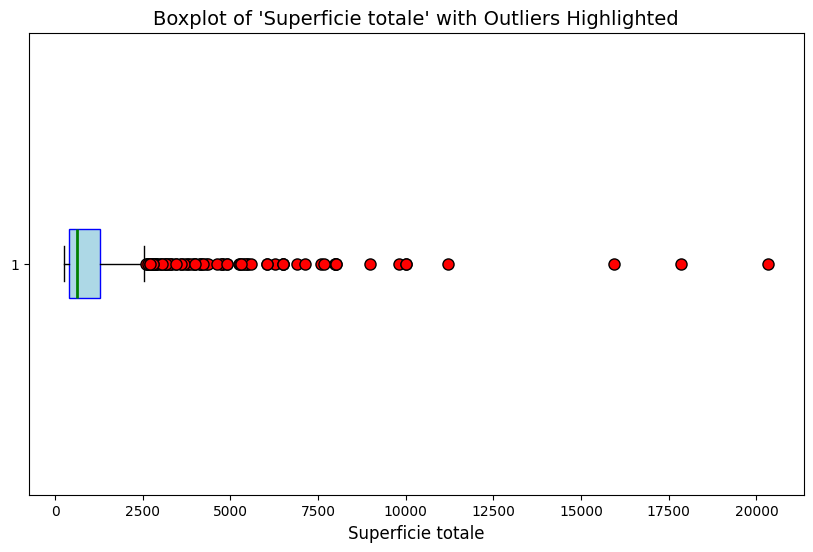

In [42]:
import matplotlib.pyplot as plt

# Boxplot for 'Superficie totale'
plt.figure(figsize=(10, 6))
plt.boxplot(MI_COMM_ACTIVITIES['Superficie totale'], vert=False, patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='blue'),
            flierprops=dict(marker='o', color='red', markersize=8, markerfacecolor='red'),
            medianprops=dict(color='green', linewidth=2))

# Add labels and title
plt.title("Boxplot of 'Superficie totale' with Outliers Highlighted", fontsize=14)
plt.xlabel("Superficie totale", fontsize=12)
plt.show()

The 5 most evident outliers are displayed in detail below:

In [43]:
outliers_sorted = outliers.sort_values(by='Superficie totale', ascending=False)
top_5_outliers = outliers_sorted.head(5)

MI_COMM_ACTIVITIES.loc[top_5_outliers.index]

,Insegna,Ubicazione,Tipo Via,Via,Civico,Codice Via,ZD,Superficie vendita,Superficie altri usi,Superficie totale,alimentare,non alimentare,tabella speciale carburanti,tabella speciale monopolio,tabella speciale farmacie,Isolato,Accesso
9,la rinascente s.p.a.,VIA SANTA RADEGONDA N. 3 11 piani (10 f.t. e 1...,VIA,SANTA RADEGONDA,3,208,1,20340,0,20340,1,1,0,0,0,417,accesso esterno
708,fiat succ. vendita assist,VIA GROSIO N. 9 ; isolato:202; accesso: access...,VIA,GROSIO,9,7483,8,675,17183,17858,0,1,0,0,0,202,accesso esterno
5,NaN,VIA ROGOREDO (in cassaforte) num.000; (z.d. 4),VIA,ROGOREDO,0,4373,4,15930,0,15930,0,0,0,0,0,<NA>,None
802,media world,VLE TROYA CARLO N. 18 ; isolato:166; accesso: ...,VLE,TROYA CARLO,18,5140,6,2350,8850,11200,0,1,0,0,0,166,accesso interno
176,la rinascente s.p.a.,VLE CERTOSA N. 29 ; isolato:330; accesso: acce...,VLE,CERTOSA,29,7174,8,6350,3670,10020,1,1,0,0,0,330,accesso esterno


We can observe that these are not anomalies that need to be corrected, as the first and fifth entries are simply two locations of "La Rinascente," the second is a Fiat dealership with both sales and service departments, the fourth represents a MediaWorld store, and for the third, we only know the street name.

The second and third are the ones that raise more suspicion: the second because it has a large area used for other purposes, while the third has a large sales area, but we do not have its sign. Without additional data, we cannot verify their accuracy, so we will consider them valid.

## 3. DUPLICATE DETECTION

### 3.1) EXACT MATCHING


The next step involves carefully checking the dataset for any duplicate rows.

We identify and remove the only duplicate found, as duplicates do not contribute additional value to the analysis and could introduce unnecessary data redundancy or distort the results.





In [44]:
DUPLICATES = MI_COMM_ACTIVITIES.duplicated()
print(DUPLICATES.any())

True


In [45]:
MI_COMM_ACTIVITIES = MI_COMM_ACTIVITIES.drop_duplicates(keep="first")
print(MI_COMM_ACTIVITIES.duplicated().any())

False


### 3.2) SIMILARITY MEASURES

In [46]:
def jaccard_similarity(str1, str2):
    if (not str1 or not str2):
      return 0.0

    set1 = set(str1.split())
    set2 = set(str2.split())

    intersection = set1.intersection(set2)
    union = set1.union(set2)
    jaccard_sim = len(intersection) / len(union)

    return jaccard_sim

In [47]:
def jaro_winkler_similarity(str1, str2):
  if (not str1 or not str2):
    return 0.0
  return jaro.jaro_winkler_metric(str1, str2)

* 'Insegna': we compute the similarity scores based on Jaro-Winkler. We remove common words before doing the comparison

In [48]:
def remove_common_words(name, common_words):
    pattern = r'\b(?:' + '|'.join(common_words) + r')\b'
    return re.sub(pattern, '', name, flags=re.IGNORECASE).strip()

In [49]:
names = MI_COMM_ACTIVITIES['Insegna'].dropna().astype(str).tolist()
common_words = ['supermercato', 'discount', 'abbigliamento', 'market', 'arredamenti', 'libreria', 'supermercati', 'supermarket', 'mobili', 'farmacia', 'emporio']
compared_pairs = set()

for i, name1 in enumerate(names):
    for j, name2 in enumerate(names):
        if i < j:

            comparison_pair = tuple(sorted([name1, name2]))

            if comparison_pair not in compared_pairs:
                # Remove common words
                filtered_name1 = remove_common_words(name1, common_words)
                filtered_name2 = remove_common_words(name2, common_words)

                # Compute Jaro-Winkler similarity
                jw_similarity = jaro_winkler_similarity(filtered_name1, filtered_name2)

                # Print only if there is similarity higher than 0.85
                if 0.85 < jw_similarity < 1.00 :
                    print(f"'{name1}' e '{name2}' simili: JW = {jw_similarity:.2f}")

                compared_pairs.add(comparison_pair)

'esselunga' e 'esselunga centro commerci' simili: JW = 0.87
'esselunga' e 'esselunga spa.' simili: JW = 0.93
'esselunga' e 'esselunga vle certosa' simili: JW = 0.89
'esselunga' e 'esselunga vle jenner' simili: JW = 0.89
'la rinascente s.p.a.' e 'la rinascente' simili: JW = 0.91
'punto sma' e 'punto market' simili: JW = 0.91
'crai' e 'cai' simili: JW = 0.92
'di perdi' e 'di per di' simili: JW = 0.97
'di per di' e 'di x di' simili: JW = 0.87
'di per di' e 'supermercati di x di' simili: JW = 0.87
'di x di' e 'di x di il supermercato' simili: JW = 0.92
'di x di il supermercato' e 'supermercati di x di' simili: JW = 0.92
'esselunga centro commerci' e 'esselunga vle certosa' simili: JW = 0.86
'esselunga spa.' e 'esselunga vle certosa' simili: JW = 0.89
'esselunga vle certosa' e 'esselunga vle jenner' simili: JW = 0.91
'euro discount' e 'etro' simili: JW = 0.85
'euro discount' e 'euroarredi' simili: JW = 0.88
'euro discount' e 'euronics' simili: JW = 0.90
'euro discount' e 'euronics point' si

In [50]:
mapping = {
    'esselunga spa.': 'esselunga',
    'esselunga centro commerci': 'esselunga',
    'esselunga vle certosa': 'esselunga',
    'esselunga vle jenner': 'esselunga',
    'la rinascente s.p.a.': 'la rinascente',
    'la rinascente duomo': 'la rinascente',
    'cai': 'crai',
    'di perdi': 'di per di',
    'di  per di': 'di per di',
    'di  x di': 'di per di',
    'di x di': 'di per di',
    'supermercati di x di': 'di per di',
    'di x di il supermercato': 'di per di',
    'io brico': 'brico io',
    'lidl supermarket': 'lidl',
    'ld market': 'ld discount',
    'mondadori mulitcenter': 'mondadori',
    'mondadori informatica': 'mondadori',
    'mondadori multicenter': 'mondadori',
    'naturasi': 'natura si',
    'standa superfresco': 'standa',
    'superdi  supermercati': 'super di',
    'upim sma': 'upim',
    'combipel': 'conbipel',
    'd  E  g.': 'd e g',
    'd E g': 'd e g',
    'd. E  g.': 'd e g',
    'd. E g.':'d e g',
    'ecliss top garden': 'ecliss',
    'euronics point': 'euronics',
    'max  E  co.': 'max mara',
    'max  E  co max mara': 'max mara',
    'maxmara': 'max mara',
    'mercedes benz milano': 'mercedes benz',
    'ricordi medi store': 'ricordi media store'
}
MI_COMM_ACTIVITIES['Insegna'] = MI_COMM_ACTIVITIES['Insegna'].replace(mapping)

Reiteration using Jaccard Similarity: here we do the comparisons without filtering out common words

In [51]:
names = MI_COMM_ACTIVITIES['Insegna'].dropna().astype(str).tolist()

compared_pairs = set()

for i, name1 in enumerate(names):
    for j, name2 in enumerate(names):
        if i < j:

            comparison_pair = tuple(sorted([name1, name2]))


            if comparison_pair not in compared_pairs:

                # Use Jaccard to compute similarity
                jac_similarity = jaccard_similarity(name1, name2)

                # Print only if the similarity is greater or equal to  0.5
                if 0.5 <= jac_similarity < 1.00 :
                    print(f"'{name1}' e '{name2}' simili: Jaccard = {jac_similarity:.2f}")

                compared_pairs.add(comparison_pair)

'punto sma' e 'sma' simili: Jaccard = 0.50
'cityper sma' e 'sma' simili: Jaccard = 0.50
'coop' e 'si coop' simili: Jaccard = 0.50
'discount' e 'euro discount' simili: Jaccard = 0.50
'discount' e 'ld discount' simili: Jaccard = 0.50
'discount' e 'pd discount' simili: Jaccard = 0.50
'gs' e 'gs supermercato' simili: Jaccard = 0.50
'gs supermercato' e 'supermercato' simili: Jaccard = 0.50
'ipercoop' e 'interno ipercoop' simili: Jaccard = 0.50
'licenza madre ce de angel' e 'licenza madre ce palizzi' simili: Jaccard = 0.50
'sma' e 'sma supermercati' simili: Jaccard = 0.50
'sma supermercati' e 'sma supermercati alimenta' simili: Jaccard = 0.67
'unes' e 'unes supermercati' simili: Jaccard = 0.50
'armani giorgio retail srl' e 'giorgio armani' simili: Jaccard = 0.50
'bruno castoldi' e 'castoldi' simili: Jaccard = 0.50
'max E co' e 'max E co.' simili: Jaccard = 0.50
'max E co' e 'max E co max mara' simili: Jaccard = 0.75
'max E co max mara' e 'max mara' simili: Jaccard = 0.50
'mercedes benz' e 'm

In [52]:
mapping = {
    'punto sma': 'sma',
    'sma supermercati': 'sma',
    'pd discount':'ld discount',
    'cityper sma': 'sma',
    'sma supermercati alimenta':'sma',
    'gs supermercato':'gs',
    'unes supermercati':'unes',
    'max E co':'max E co.',
    'max E co max mara':'max E co.',
    'd E g.':'d e g',
    'si coop':'coop',
    'interno ipercoop':'ipercoop',
    'armani giorgio retail srl':'giorgio armani',
    'castoldi':'bruno castoldi',
    'milano star mercedes benz':'mercedes benz',
    'special market dugan':'dugan'
}
MI_COMM_ACTIVITIES['Insegna'] = MI_COMM_ACTIVITIES['Insegna'].replace(mapping)

* Via: to identify similarities, we use Jaccard Similarity for strings because a 'Via' is composed by multiple names

In [53]:
names = MI_COMM_ACTIVITIES['Via'].astype(str).tolist()
compared_pairs = set()

for i, name1 in enumerate(names):
    for j, name2 in enumerate(names):
        if i < j:

            comparison_pair = tuple(sorted([name1, name2]))

            if comparison_pair not in compared_pairs:

                jaccard = jaccard_similarity(name1, name2)

                # Print only if the similarity is greater or equal to  0.5
                if 0.5 <= jaccard < 1.00:

                    print(f"Similarità Jaro-Winkler tra '{name1}' e '{name2}': {jaccard:.2f}")

                compared_pairs.add(comparison_pair)

Similarità Jaro-Winkler tra 'DI PTA TICINESE' e 'DI PORTA TICINESE': 0.50
Similarità Jaro-Winkler tra 'DEL DUOMO' e 'DUOMO': 0.50
Similarità Jaro-Winkler tra 'PIRELLI GIOVANNI BATTISTA' e 'SCALABRINI GIOVANNI BATTISTA': 0.50
Similarità Jaro-Winkler tra 'PIRELLI GIOVANNI BATTISTA' e 'GRASSI GIOVANNI BATTISTA': 0.50
Similarità Jaro-Winkler tra 'PIRELLI GIOVANNI BATTISTA' e 'CASSINIS GIOVANNI BATTISTA': 0.50
Similarità Jaro-Winkler tra 'PIRELLI GIOVANNI BATTISTA' e 'SORESINA GIOVANNI BATTISTA': 0.50
Similarità Jaro-Winkler tra 'PIRELLI GIOVANNI BATTISTA' e 'PIRANESI GIOVANNI BATTISTA': 0.50
Similarità Jaro-Winkler tra 'GIOVANNI DA CERMENATE' e 'GIOVANNI DA PROCIDA': 0.50
Similarità Jaro-Winkler tra 'GIOVANNI DA CERMENATE' e 'GIOVANNI DA UDINE': 0.50
Similarità Jaro-Winkler tra 'DI PORTA VIGENTINA' e 'DI PORTA VOLTA': 0.50
Similarità Jaro-Winkler tra 'DI PORTA VIGENTINA' e 'DI PORTA TICINESE': 0.50
Similarità Jaro-Winkler tra 'DI PORTA VIGENTINA' e 'DI PORTA VERCELLINA': 0.50
Similarità Ja

Based on the output, we can perform the following operations:

* Reconcile 'DI PTA TICINESE' and 'DI PORTA TICINESE'

In [54]:
MI_COMM_ACTIVITIES.loc[MI_COMM_ACTIVITIES['Via'] == 'DI PTA TICINESE', 'Via'] = 'DI PORTA TICINESE'

* Reconcile 'DUOMO' and 'DEL DUOMO'

In [55]:
MI_COMM_ACTIVITIES.loc[MI_COMM_ACTIVITIES['Via'] == 'DUOMO', 'Via'] = 'DEL DUOMO'

* Reconcile 'VITTORIO EMANUELE II' and 'VITTORIO EMANUELE'

In [56]:
MI_COMM_ACTIVITIES.loc[MI_COMM_ACTIVITIES['Via'] == 'VITTORIO EMANUELE', 'Via'] = 'VITTORIO EMANUELE II'

---

## 4. REITERATION: NEW CONSITENCY CHECKS

After performing the data deduplication, we can perform one more consistency check

* Same 'Via' implies same 'Tipo Via' and same 'ZD'

In [57]:
# Group by 'Via'
grouped = MI_COMM_ACTIVITIES.groupby('Via')

# Initialize counters
total_groups = MI_COMM_ACTIVITIES['Via'].nunique()
correct_count = 0

# Analyze each group and check for discrepancies
for via, group in grouped:
    unique_combinations = group[['ZD', 'Tipo Via']].drop_duplicates()
    if len(unique_combinations) > 1:
        print(f"Discrepancy found for Via '{via}':")
        print(unique_combinations)
    else:
        correct_count += 1

# Calculate the percentage of correct streets
correct_percentage = (correct_count / total_groups) * 100
print(f"\nPercentage of correct streets: {correct_percentage:.2f}%")
print(f"\nTotal unique groups: {total_groups}")

Discrepancy found for Via 'ASTESANI ALESSANDRO':
     ZD Tipo Via
3     8      VIA
251   9      VIA
Discrepancy found for Via 'BUENOS AIRES':
     ZD Tipo Via
56    3      CSO
657   3      GLL
Discrepancy found for Via 'CASATI FELICE':
     ZD Tipo Via
117   2      VIA
147   3      VIA
Discrepancy found for Via 'DEL DUOMO':
     ZD Tipo Via
22    1      PZA
340   1      PAS
Discrepancy found for Via 'DI PORTA TICINESE':
     ZD Tipo Via
1     1      RIP
305   1      CSO
358   6      RIP
Discrepancy found for Via 'IMPERIA':
     ZD Tipo Via
440   5      VIA
659   6      VIA
Discrepancy found for Via 'INDIPENDENZA':
     ZD Tipo Via
309   3      CSO
310   4      CSO
Discrepancy found for Via 'LODI':
     ZD Tipo Via
68    4      CSO
166   4      PLE
645   5      CSO
Discrepancy found for Via 'LORETO':
     ZD Tipo Via
102   3      PLE
287   2      PLE
Discrepancy found for Via 'MEDA GIUSEPPE':
     ZD Tipo Via
455   5      VIA
749   1      VIA
Discrepancy found for Via 'PASSARELLA':
    

Taking a quick look at the various cases of discrepancies identified above, it can be deduced that all these "Via" values are actually correct.

In fact, in cases where the ZD values differ, the explanation is that the street is located exactly on the border between two zones.

Regarding the Tipo Via, it is often the case that in some areas, galleries or squares are found next to the main street, and they share the same name.



---



## 5. REORDERING THE COLUMNS



> Once the data wrangling is complete, we can finally reorder the columns, delete the unnecessary ones, and rename them as desired.

In [58]:
# 1. Drop the 'Ubicazione' column
MI_COMM_ACTIVITIES = MI_COMM_ACTIVITIES.drop(columns=['Ubicazione'])

# 2. Reorder the columns in the desired order
column_order = [
    'Insegna', 'Tipo Via', 'Via', 'Civico', 'Codice Via', 'Isolato',
    'Accesso', 'ZD', 'Superficie vendita', 'Superficie altri usi',
    'Superficie totale', 'alimentare', 'non alimentare',
    'tabella speciale carburanti', 'tabella speciale monopolio', 'tabella speciale farmacie'
]

MI_COMM_ACTIVITIES = MI_COMM_ACTIVITIES[column_order]

# 3. Rename specific columns
MI_COMM_ACTIVITIES.rename(columns={
    'alimentare': 'Alimentare',
    'non alimentare': 'Non alimentare',
    'tabella speciale carburanti': 'Tabella speciale carburanti',
    'tabella speciale monopolio': 'Tabella speciale monopolio',
    'tabella speciale farmacie': 'Tabella speciale farmacie'
}, inplace=True)

In [59]:
# Reorder the rows sorting by 'Insegna'
MI_COMM_ACTIVITIES = MI_COMM_ACTIVITIES.sort_values(by='Insegna')

In [60]:
MI_COMM_ACTIVITIES.head()

,Insegna,Tipo Via,Via,Civico,Codice Via,Isolato,Accesso,ZD,Superficie vendita,Superficie altri usi,Superficie totale,Alimentare,Non alimentare,Tabella speciale carburanti,Tabella speciale monopolio,Tabella speciale farmacie
595,2f climatizzazione,VIA,INGANNI ANGELO,64,6672,55,accesso esterno,6,264,36,300,0,1,0,0,0
597,a. bellomi,VIA,LOMELLINA,64,3280,219,accesso interno,4,400,500,900,0,1,0,0,0
600,a.foppapedretti l albero,VIA,MAMBRETTI ANTONIO,9,7455,118,accesso esterno,8,506,0,506,0,1,0,0,0
596,abbigliamento bambino,VIA,BALZARETTI GIUSEPPE,28,2197,109,accesso esterno,3,268,0,268,0,1,0,0,0
598,aber crombie e fich,CSO,MATTEOTTI GIACOMO,12,218,316,accesso esterno,1,1496,690,2186,0,1,0,0,0


---

# SAVING THE CLEANED DATASET

In [61]:
# Save the DataFrame to an Excel file
MI_COMM_ACTIVITIES.to_excel('MI_COMM_ACTIVITIES.xlsx', index=False)